## Informe Minería de Datos 001V

### **Profesor:**
* Bryhan Israel Cortes Rodriguez

### **Integrantes:** 
* Eduardo Bravo
* Erick Diaz
* Bryan Muñoz

## Introducción

El presente informe desarrolla el caso semestral de Minería de Datos siguiendo la metodología **CRISP-DM** sobre el dataset `weatherAUS`, el cual contiene observaciones meteorológicas diarias recopiladas en múltiples ciudades de Australia.

El análisis abarca las tres primeras etapas del proceso: Comprensión del Negocio, Comprensión de los Datos (análisis exploratorio) y Preparación de los Datos, dejando el dataset completamente preparado para la etapa de Modelamiento.

## Fase 1: Comprensión del Negocio

### 1.1 Descripción del Tema

Australia es el continente más seco y llano del planeta, con una superficie de 7.741.220 km². Presenta una gran diversidad climática: clima tropical en el norte (39% del territorio), clima desértico en el centro y templado en el sureste y suroeste. Esta variabilidad hace que el país esté permanentemente expuesto a fenómenos naturales extremos: sequías, inundaciones, ciclones tropicales e incendios forestales (*bushfires*).

El sector agropecuario y el sector minero —que representa el **10% del PIB australiano** con exportaciones que superan los 299.000 millones AUD— dependen directamente de las condiciones climáticas. Un evento de lluvia extremo puede paralizar operaciones, destruir cultivos o generar emergencias de gran escala. Predecir la lluvia con anticipación permite tomar decisiones estratégicas que protegen tanto la economía como la seguridad de la población.

### 1.2 Objetivo del Análisis

Desarrollar un modelo de minería de datos capaz de **predecir si lloverá al día siguiente** (`RainTomorrow = Yes / No`), utilizando las variables meteorológicas registradas durante el día actual. El modelo debe ser generalizable a nuevas observaciones para ser útil en producción real.

### 1.3 Tipo de Problema

**Clasificación binaria**: la variable objetivo `RainTomorrow` toma dos valores posibles:
- `Yes (1)`: lloverá al día siguiente
- `No (0)`: no lloverá al día siguiente

A diferencia de la regresión (que predice valores continuos como temperatura o milímetros de lluvia), la clasificación produce una decisión accionable directa.

### 1.4 Identificación de Variables del Análisis

| Grupo | Variables |
|-------|-----------|
| Temperaturas | MinTemp, MaxTemp, Temp9am, Temp3pm |
| Humedad y Presión | Humidity9am, Humidity3pm, Pressure9am, Pressure3pm |
| Viento | WindGustDir, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm |
| Condiciones atmosféricas | Sunshine, Evaporation, Cloud9am, Cloud3pm |
| Precipitación actual | Rainfall, RainToday |
| Variable objetivo | **RainTomorrow** |

### 1.5 Por qué este Problema es Relevante

La predicción precisa de lluvia tiene impacto directo en:
1. **Agricultura**: planificación de siembra, riego y cosecha en función del clima esperado
2. **Gestión de recursos hídricos**: administración de embalses, canales de riego y reservas de agua potable
3. **Emergencias y seguridad pública**: activación temprana de alertas por inundaciones o incendios
4. **Sector minero**: el 10% del PIB australiano depende de condiciones climáticas para operaciones extractivas seguras
5. **Logística y transporte**: optimización de rutas y cadena de suministro ante eventos climáticos adversos

### 1.6 Hipótesis Iniciales

- Mayor humedad relativa a las 3pm → mayor probabilidad de lluvia al día siguiente
- Menor presión atmosférica a las 3pm → mayor probabilidad de lluvia
- Las ciudades costeras (Sydney, Melbourne) presentan mayor frecuencia de lluvia que las ciudades del interior (Woomera, Alice Springs)
- El mes del año influye en la probabilidad de lluvia (estacionalidad: verano austral vs invierno)

### 1.7 Criterios de Éxito

Dado el desbalance de clases (~77% No / ~23% Yes), el modelo será evaluado principalmente con:
- **Recall** de la clase positiva: minimizar falsos negativos (predecir "no llueve" cuando sí llueve es el error más costoso)
- **F1-Score**: balance entre precisión y recall
- **AUC-ROC**: capacidad discriminativa general del modelo

## Fase 2: Comprensión de los Datos

En esta etapa se exploró el dataset `weatherAUS` con el objetivo de entender su estructura, identificar problemas en los datos y extraer conclusiones iniciales que guíen la preparación.

### Librerías a utilizar

In [1]:
%pip install seaborn pandas numpy matplotlib scikit-learn --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Librerías a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar DataFrame

In [3]:
df = pd.read_csv("Data/weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


### Descripción por columna

In [4]:
print("Dimensiones:", df.shape)
pd.set_option('display.max_columns', None)
df.info()

Dimensiones: (142193, 24)
<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am      

### Estadistica Descriptiva

In [5]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


### Valores Nulos

In [6]:
df.isnull().sum().sort_values(ascending=False)

Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
RainToday         1406
Rainfall          1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
RISK_MM              0
Date                 0
Location             0
RainTomorrow         0
dtype: int64

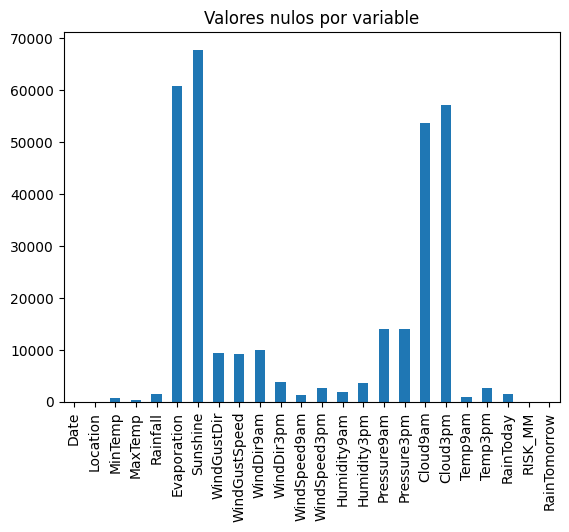

In [7]:
plt.figure()
df.isnull().sum().plot(kind='bar')
plt.title("Valores nulos por variable")
plt.xticks(rotation=90)
plt.show()

In [8]:
# Definición de listas de variables para EDA
variables_numericas = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
]

variables_categoricas = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

variable_objetivo = 'RainTomorrow'

n_cols = 4
n_rows = -(-len(variables_numericas) // n_cols)  # ceil(16/4) = 4

print(f"Variables numéricas:   {len(variables_numericas)}")
print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Grid de gráficos:      {n_rows} x {n_cols}")

Variables numéricas:   16
Variables categóricas: 4
Grid de gráficos:      4 x 4


### 2.4 Análisis Exploratorio de Variables (EDA)

#### 2.4.1 Distribuciones — Histogramas de todas las variables numéricas

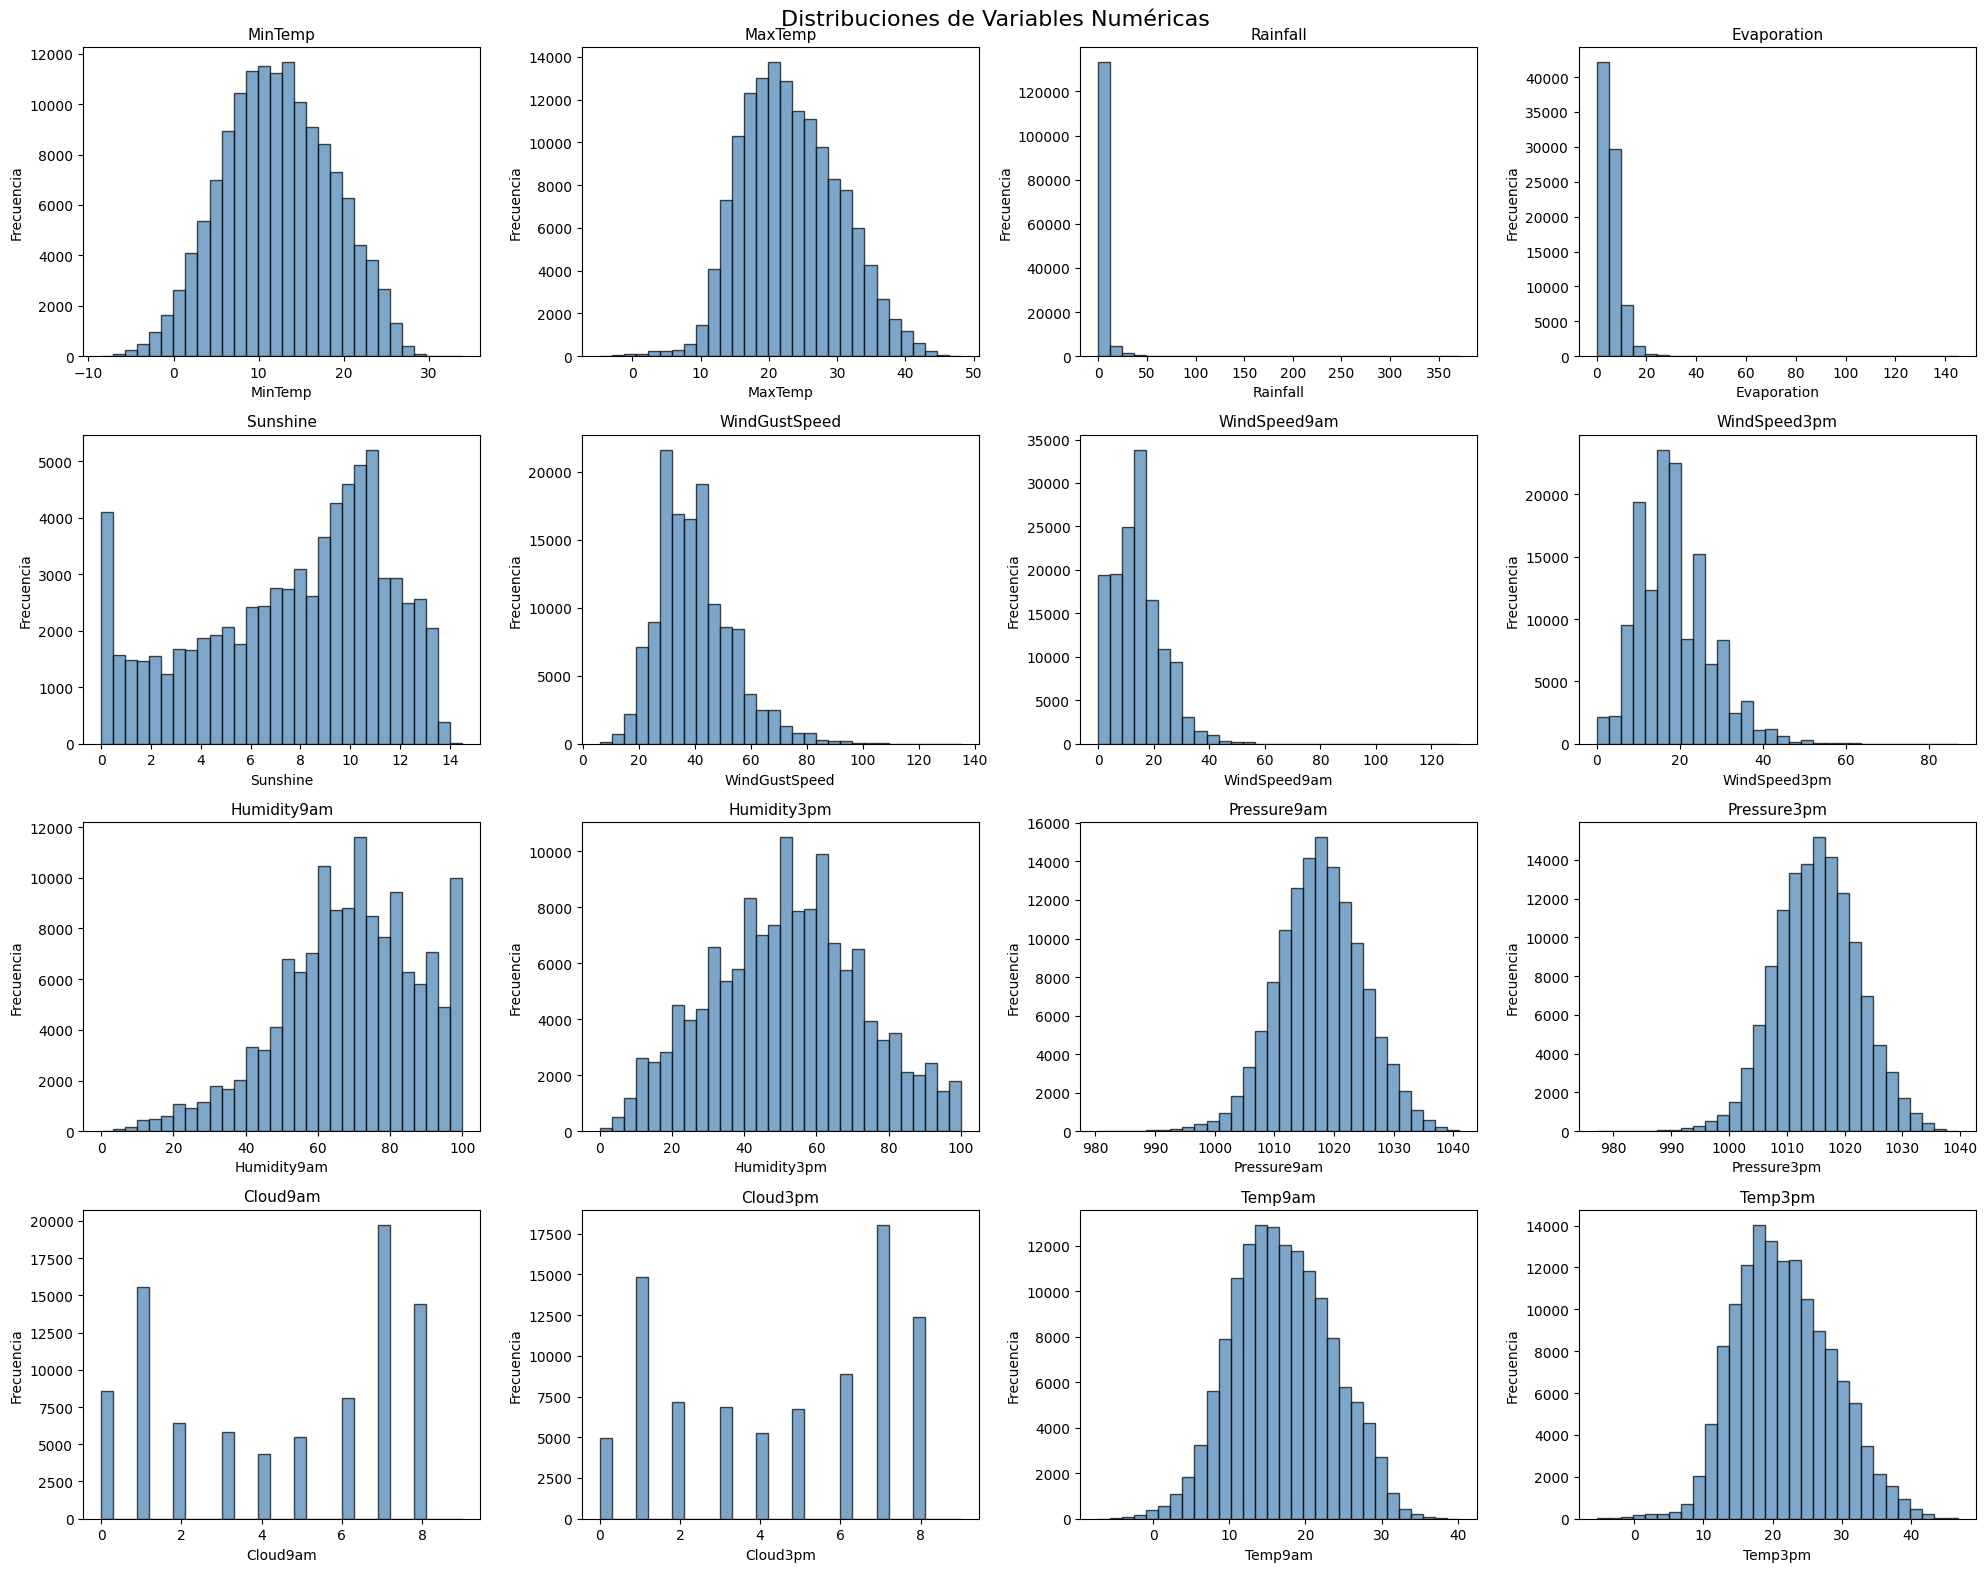

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

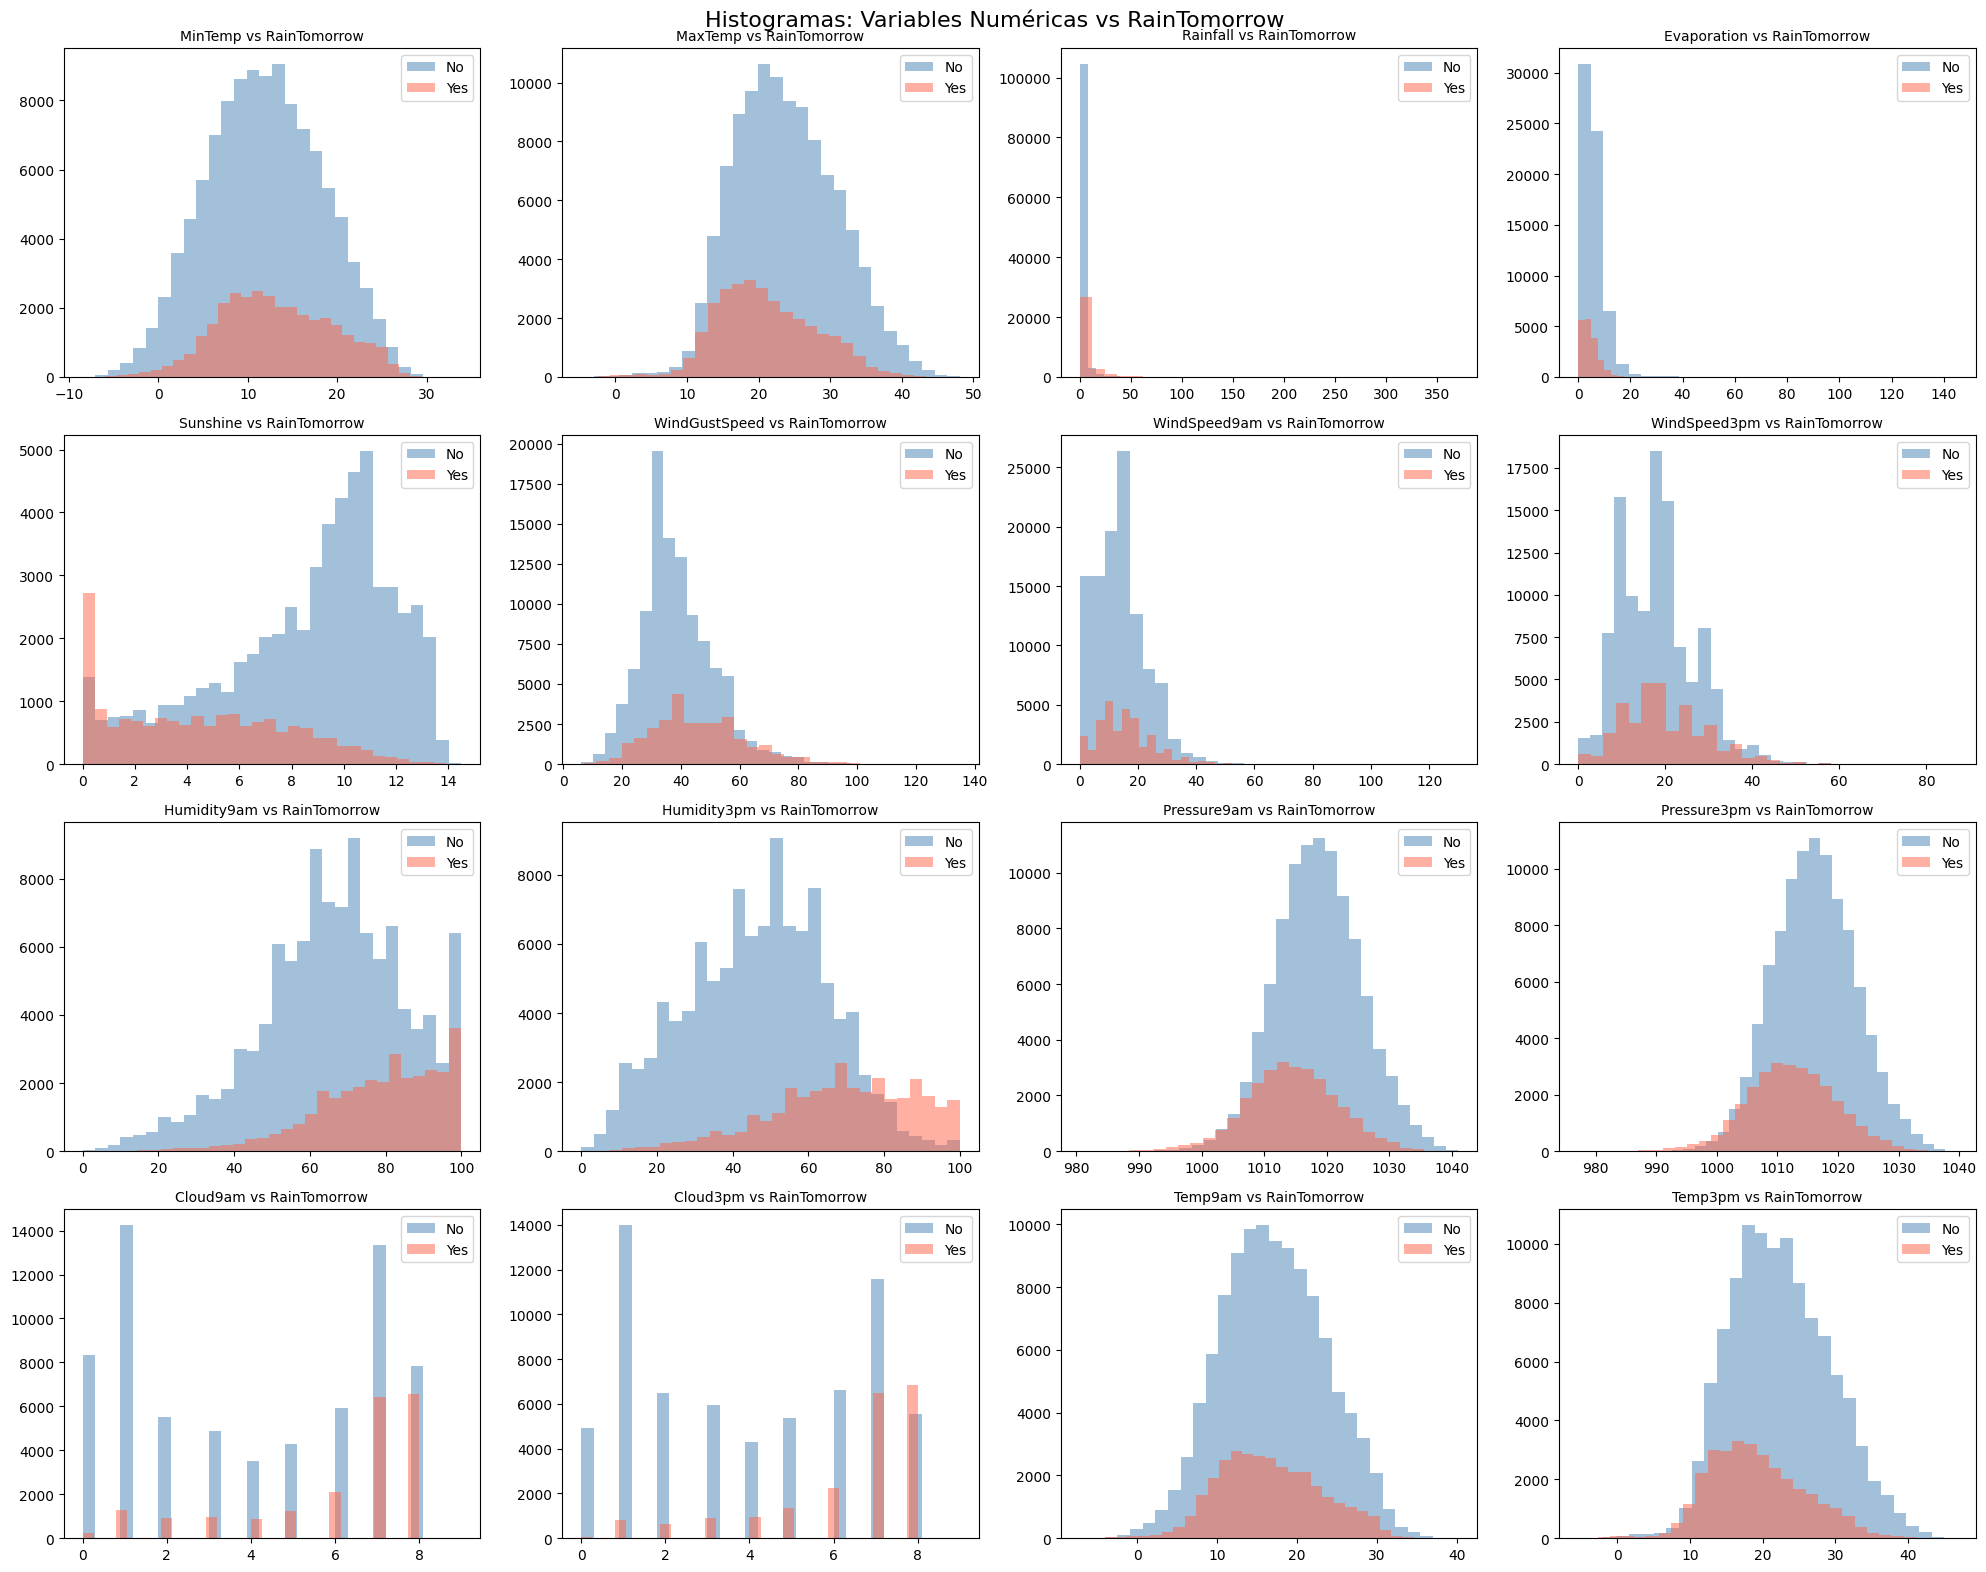

In [10]:
# Histogramas de variables numéricas vs RainTomorrow
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    for val, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
        subset = df[df[variable_objetivo] == val][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, label=val, color=color)
    axes[i].set_title(f'{col} vs {variable_objetivo}', fontsize=10)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas: Variables Numéricas vs RainTomorrow', fontsize=16)
plt.tight_layout()
plt.show()

#### 2.4.2 Detección de Outliers — Boxplots de todas las variables numéricas

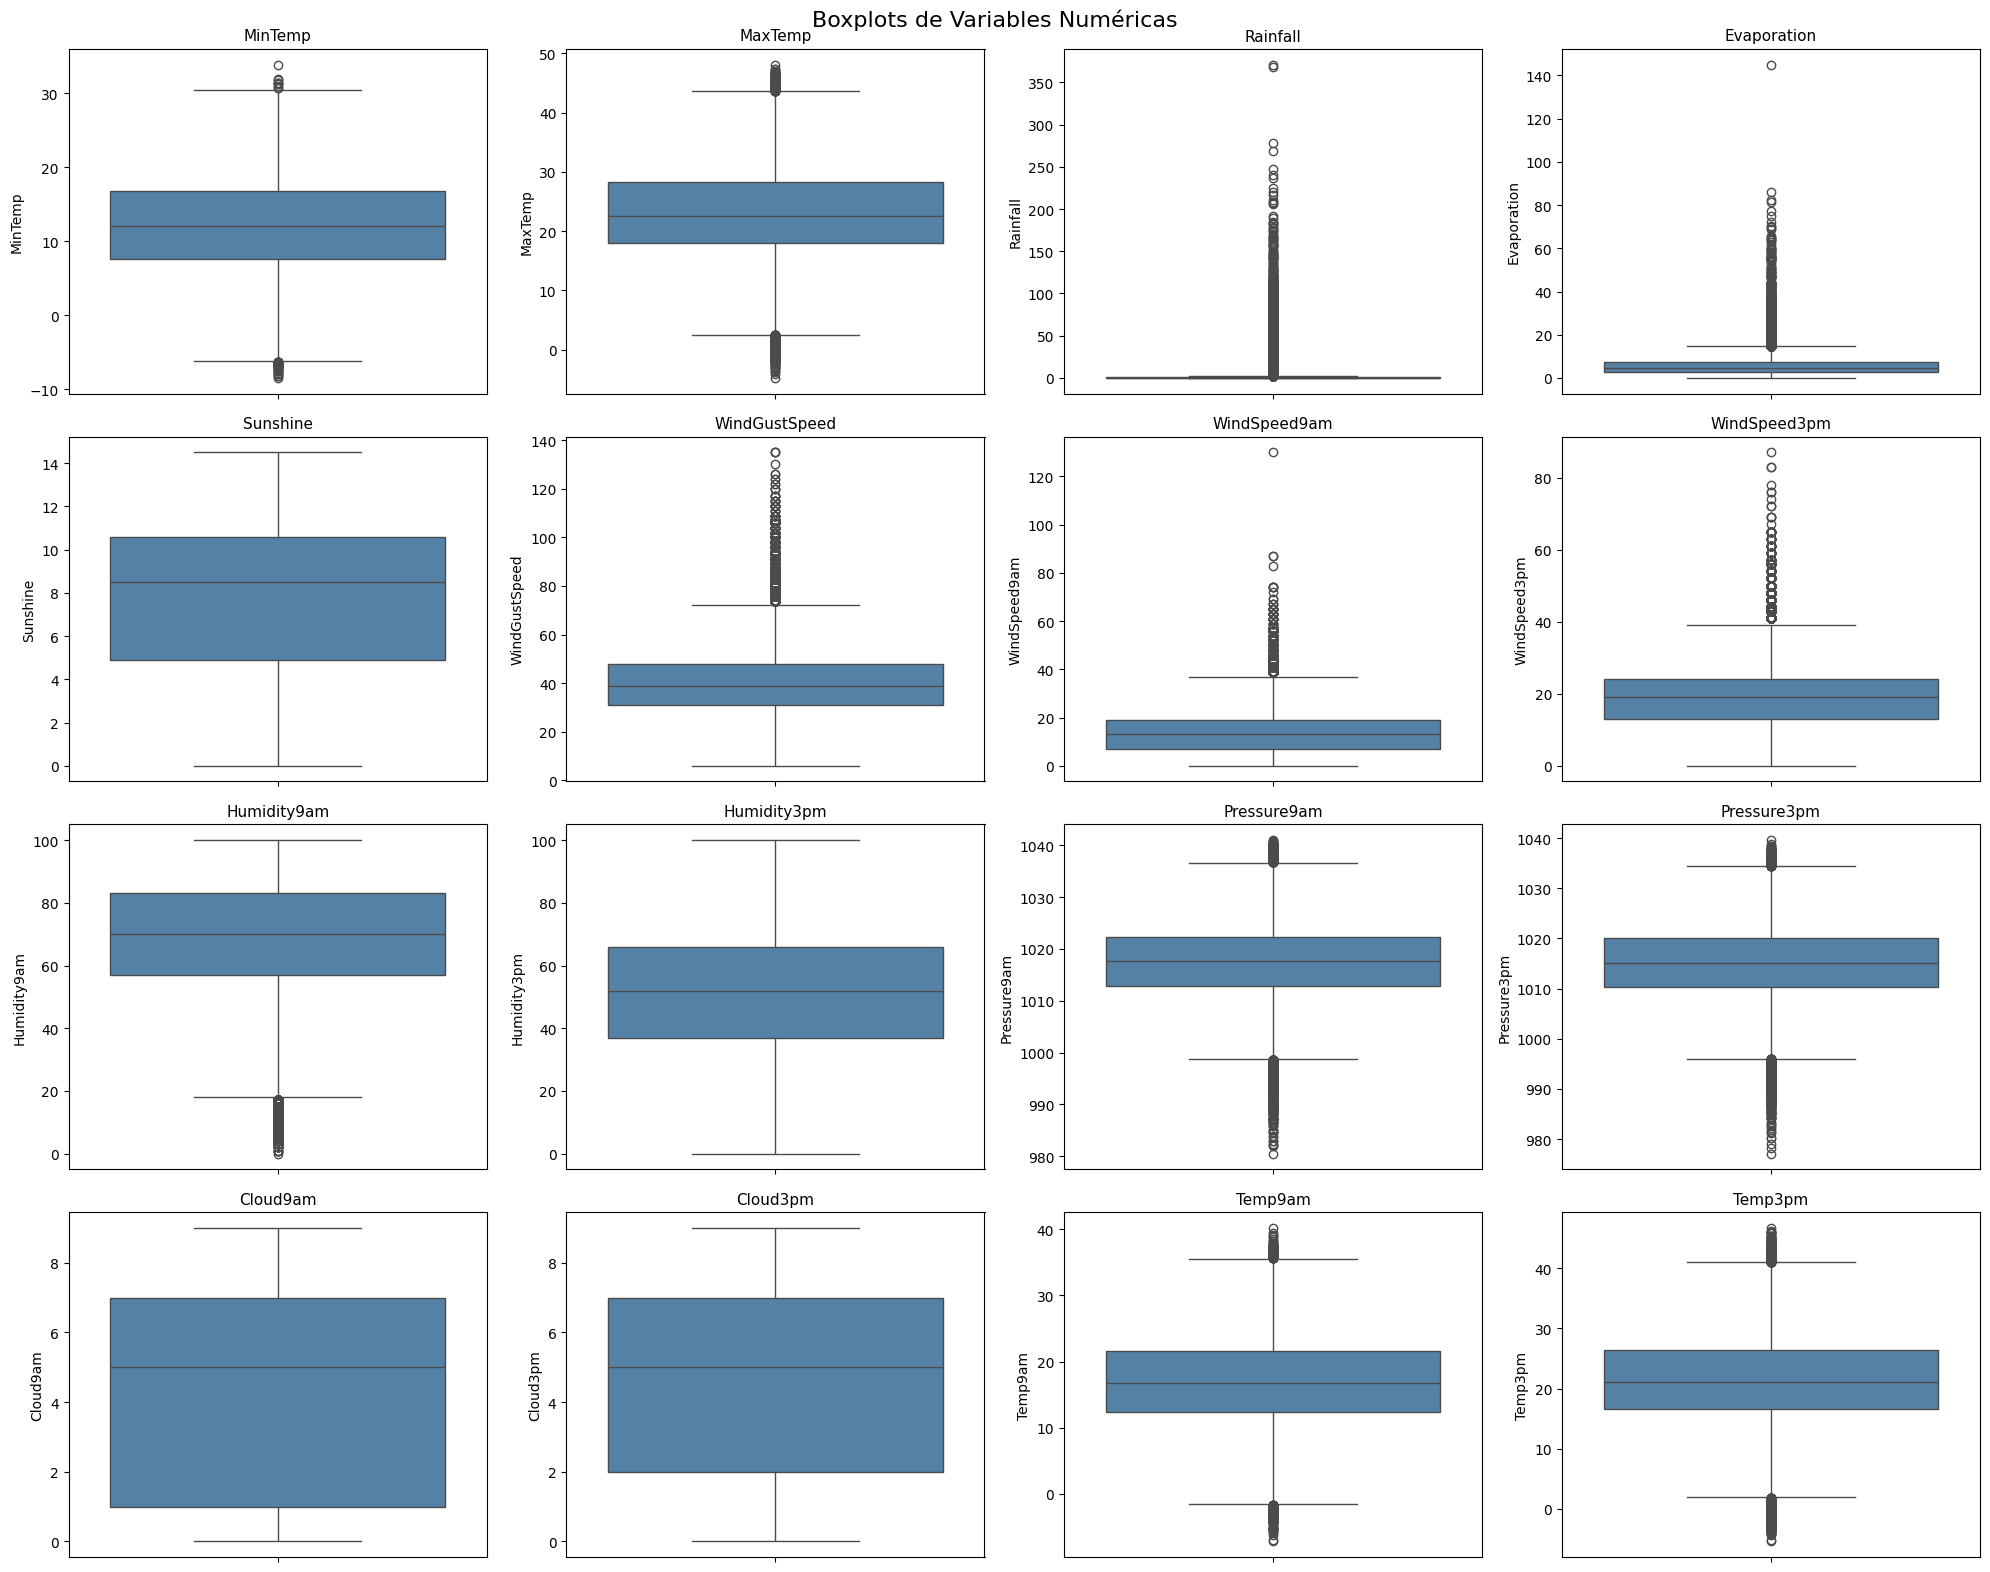

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de Variables Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

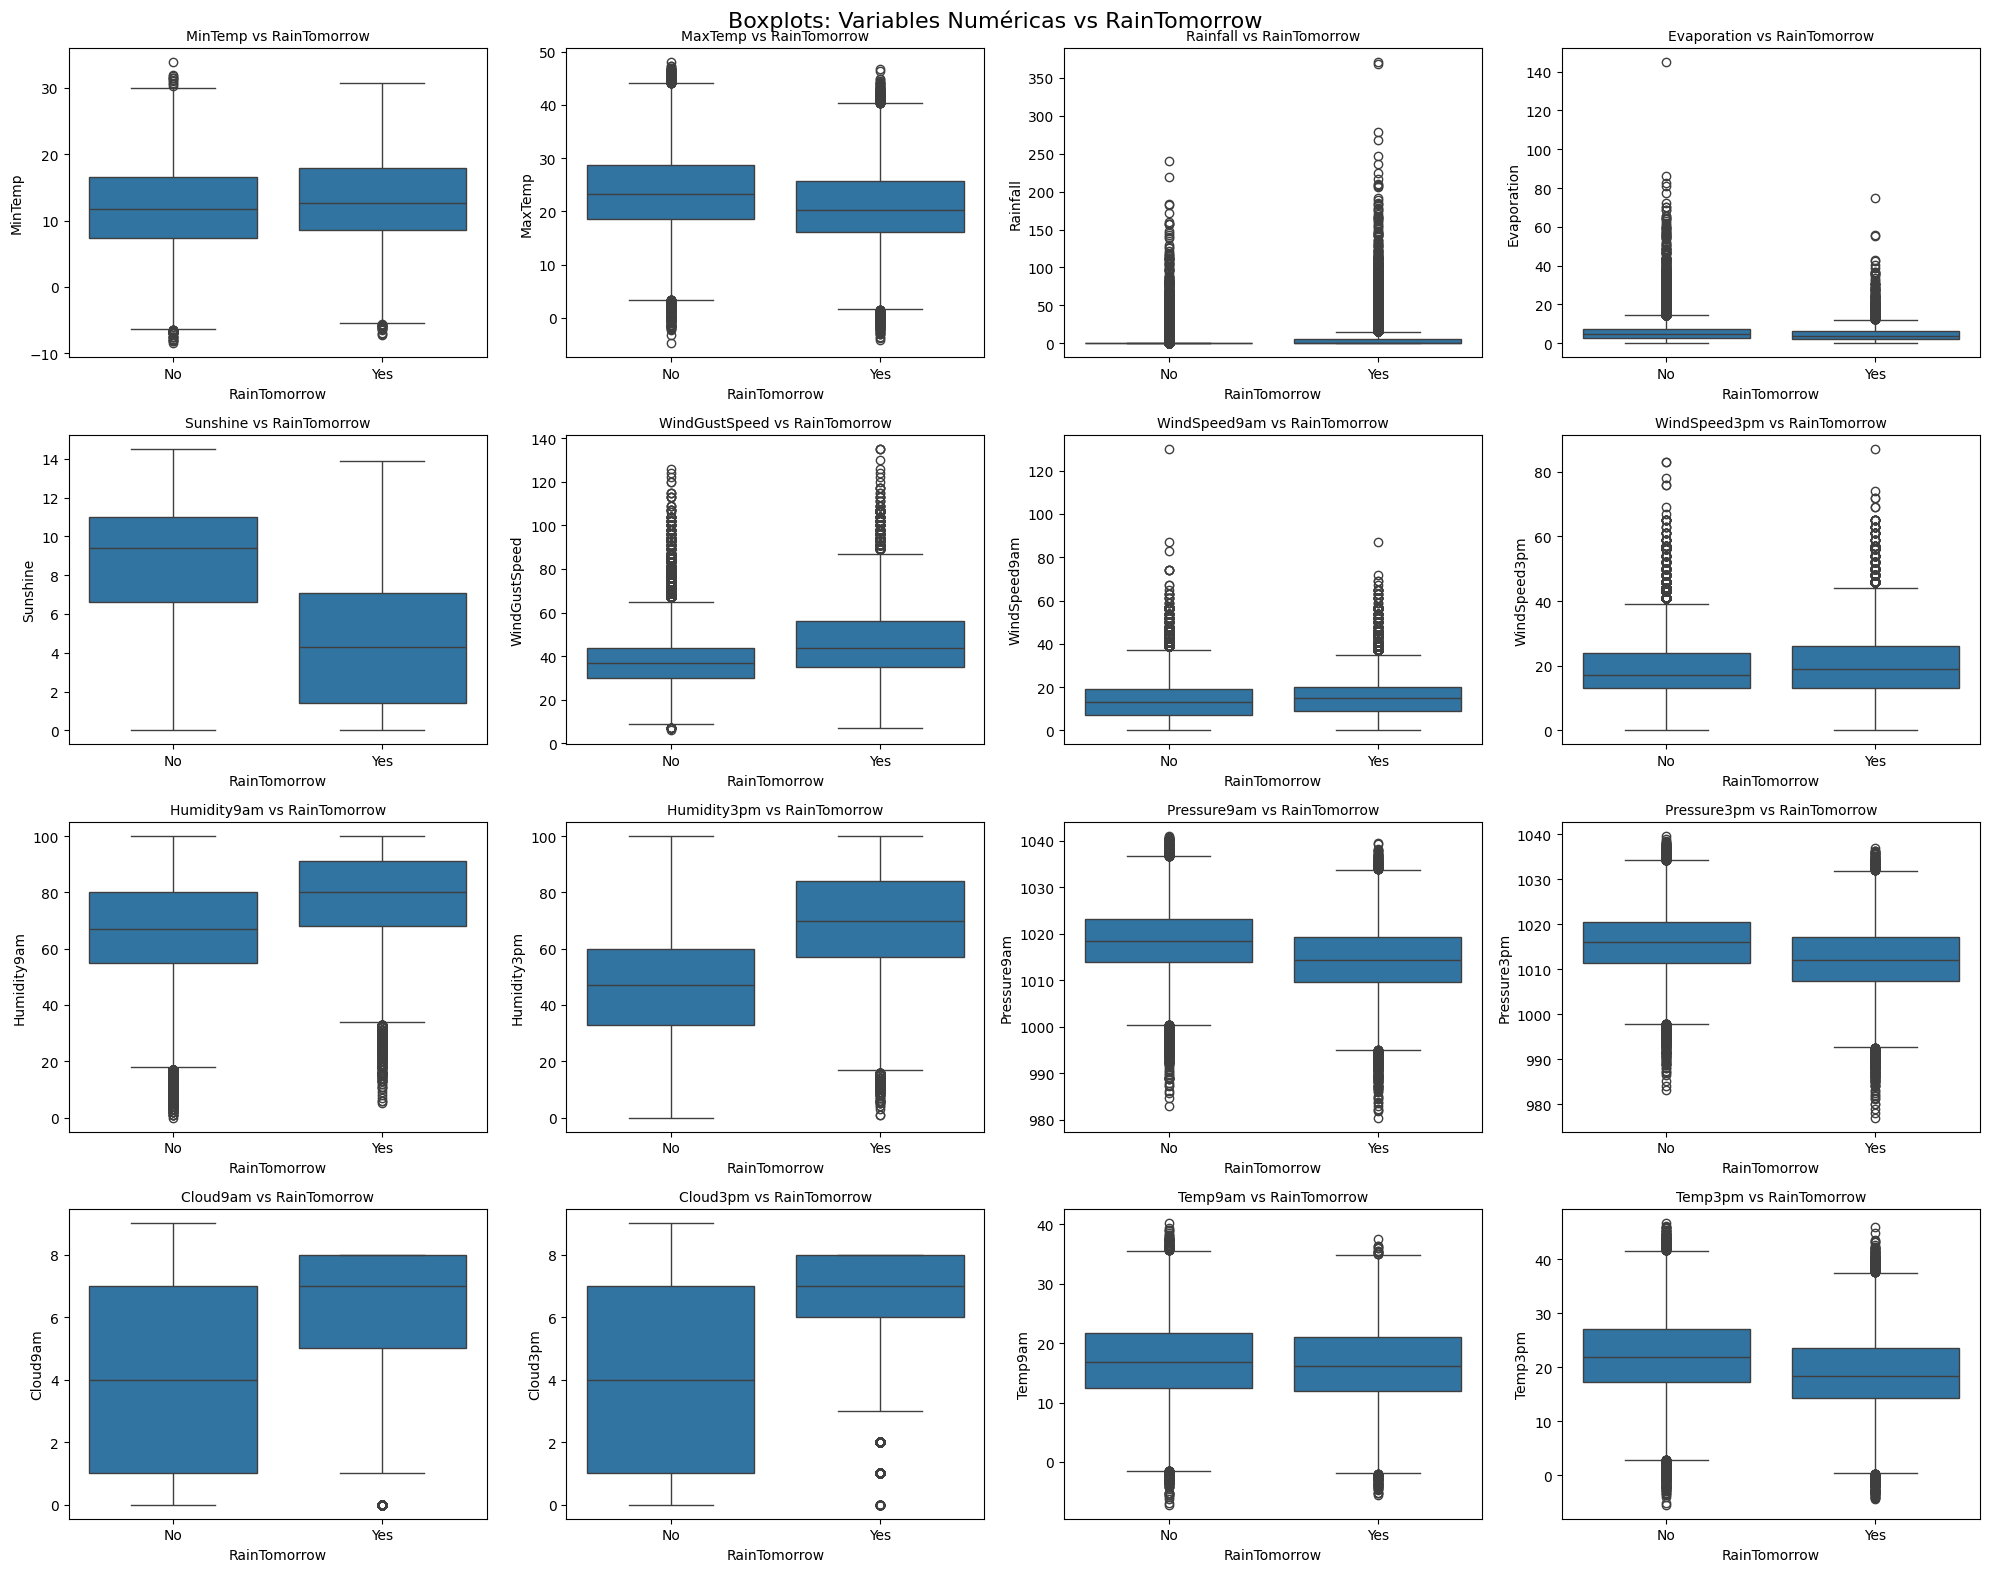

In [12]:
# Boxplots de variables numéricas vs RainTomorrow
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(x=variable_objetivo, y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs {variable_objetivo}', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: Variables Numéricas vs RainTomorrow', fontsize=16)
plt.tight_layout()
plt.show()

### Variables categóricas

In [13]:
df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

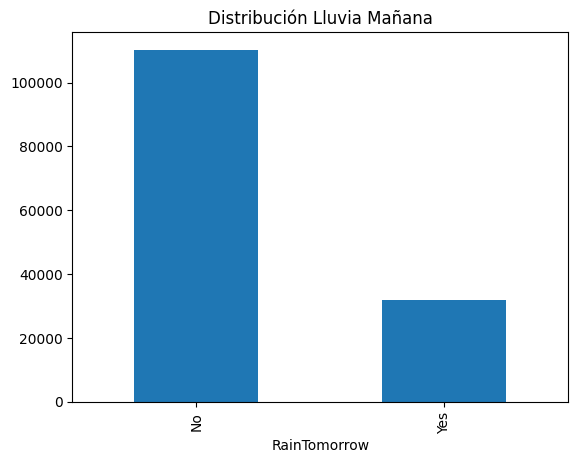

In [14]:
df['RainTomorrow'].value_counts().plot(kind='bar')
plt.title("Distribución Lluvia Mañana")
plt.show()

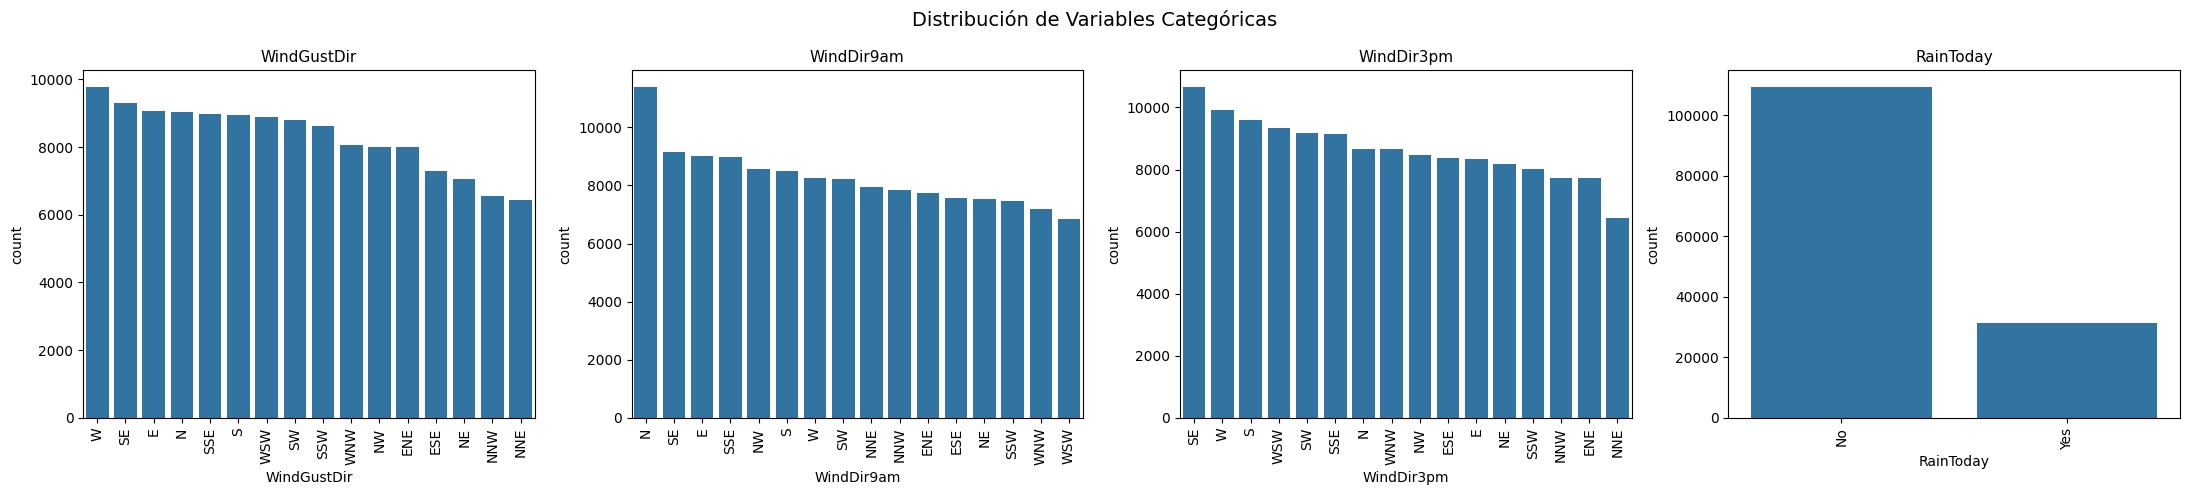

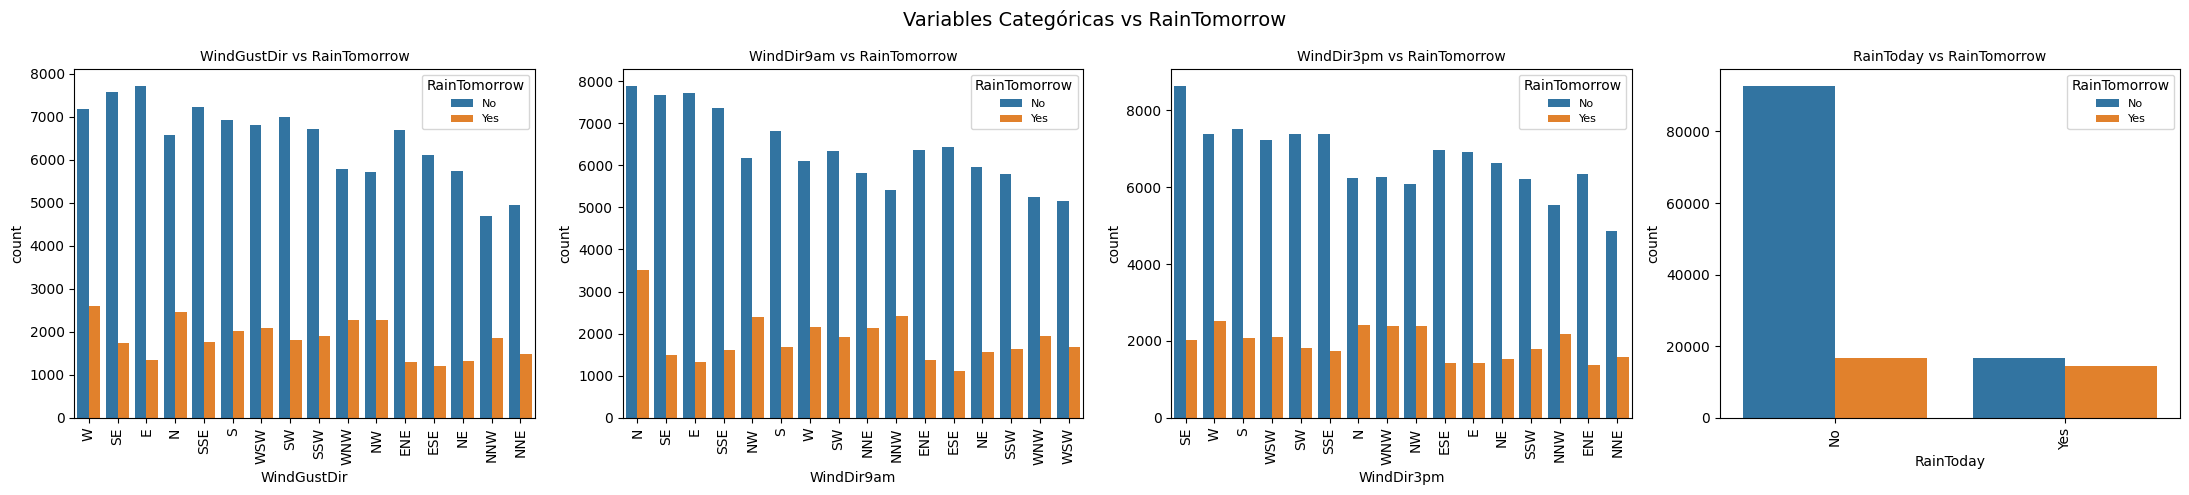

,Variable,N° Outliers,% del total
2,Rainfall,25228,17.74
5,WindGustSpeed,3006,2.11
7,WindSpeed3pm,2458,1.73
3,Evaporation,1954,1.37
6,WindSpeed9am,1739,1.22
8,Humidity9am,1419,1.00
10,Pressure9am,1174,0.83
11,Pressure3pm,906,0.64
15,Temp3pm,735,0.52
1,MaxTemp,459,0.32


In [15]:
# ── Distribución de variables categóricas ─────────────────────────
fig, axes = plt.subplots(1, len(variables_categoricas), figsize=(22, 5))

for i, col in enumerate(variables_categoricas):
    order = df[col].value_counts().index[:20]
    sns.countplot(x=col, data=df, ax=axes[i], order=order)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=90)

plt.suptitle('Distribución de Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.show()

# ── Variables categóricas vs RainTomorrow ─────────────────────────
fig, axes = plt.subplots(1, len(variables_categoricas), figsize=(22, 5))

for i, col in enumerate(variables_categoricas):
    order = df[col].value_counts().index[:20]
    sns.countplot(x=col, hue=variable_objetivo, data=df, ax=axes[i], order=order)
    axes[i].set_title(f'{col} vs {variable_objetivo}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend(title=variable_objetivo, loc='upper right', fontsize=8)

plt.suptitle('Variables Categóricas vs RainTomorrow', fontsize=14)
plt.tight_layout()
plt.show()

# ── IQR: conteo de outliers por variable numérica ─────────────────
resultados_iqr = []
for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR_val = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR_val
    lim_sup = Q3 + 1.5 * IQR_val
    n_out = int(((df[col] < lim_inf) | (df[col] > lim_sup)).sum())
    resultados_iqr.append([col, n_out, round(n_out / len(df) * 100, 2)])

df_iqr = pd.DataFrame(resultados_iqr, columns=['Variable', 'N° Outliers', '% del total'])
df_iqr.sort_values('% del total', ascending=False)

### Correlación

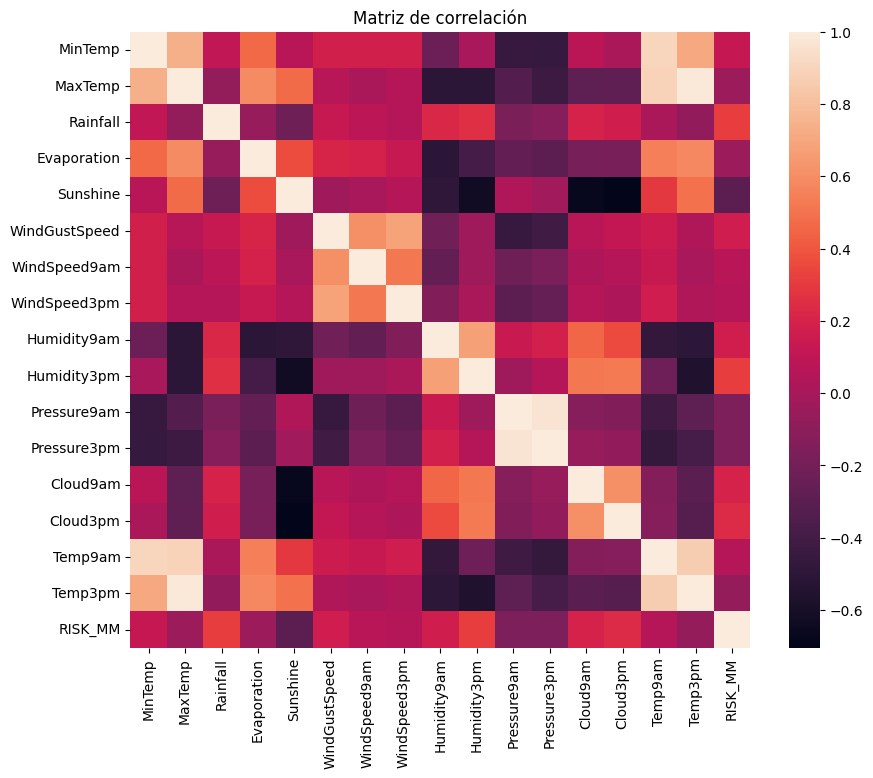

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False)
plt.title("Matriz de correlación")
plt.show()

### Relación con variable objetivo

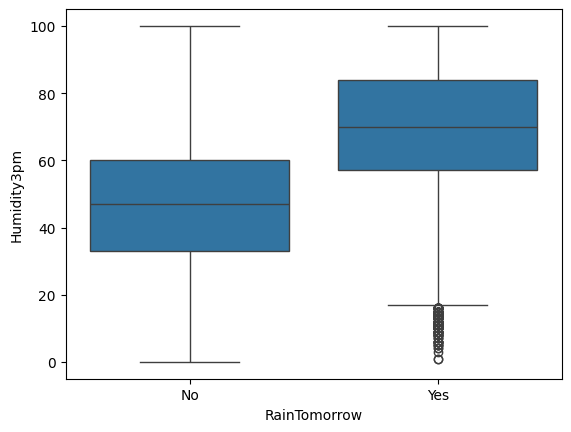

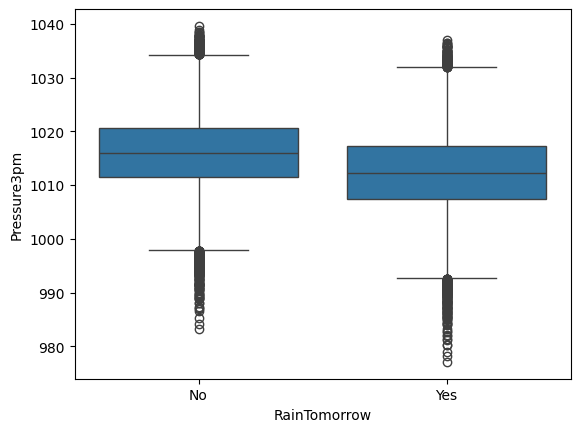

In [17]:
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.show()

sns.boxplot(x='RainTomorrow', y='Pressure3pm', data=df)
plt.show()

### Distribución de clases

In [18]:
df['RainTomorrow'].value_counts(normalize=True)

RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64

## Fase 3: Preparación de los datos

In [19]:
# Descomposición de Date en Mes y Año
df['Date'] = pd.to_datetime(df['Date'])
df['Mes']  = df['Date'].dt.month
df['Año']  = df['Date'].dt.year
df = df.drop(columns=['Date'])

In [20]:
# Eliminación de RISK_MM por data leakage
df = df.drop(columns=['RISK_MM'])

### 3.1 Imputación de Valores Nulos

La imputación se realiza con estadísticos **globales** (media, mediana o moda calculados sobre todo el dataset), sin agrupar por localidad. Esta decisión se justifica por tres razones:

1. **Estabilidad estadística**: el dataset contiene 49 localidades con tamaños de muestra muy desiguales. Calcular la media o mediana dentro de cada localidad para variables con alta tasa de nulos (Sunshine 47.7 %, Evaporation 42.8 %) produciría estimaciones inestables o incluso faltantes en localidades con pocos registros, propagando el problema en vez de resolverlo.

2. **Objetivo del modelo**: se busca un predictor generalizable a cualquier punto de Australia. Usar estadísticos locales introduce sesgos geográficos en la imputación que el modelo terminaría aprendiendo, confundiendo la señal climática real con un artefacto del preprocesamiento.

3. **Variables de baja variabilidad inter-localidad**: variables como `Pressure9am/3pm`, `Humidity9am/3pm` o las temperaturas presentan distribuciones similares a nivel nacional (confirmado en el EDA). El beneficio marginal de imputar por localidad es mínimo frente al riesgo de inestabilidad, y la estrategia global es suficiente para capturar el comportamiento central de cada variable.

| Estrategia | Variables | Razón |
|---|---|---|
| **Media** | MinTemp, MaxTemp, Temp9am, Temp3pm, Humidity9am/3pm, Pressure9am/3pm, WindGustSpeed, WindSpeed9am/3pm | Distribución aproximadamente simétrica |
| **Mediana** | Rainfall, Evaporation, Sunshine, Cloud9am, Cloud3pm | Distribución sesgada a la derecha / muchos ceros |
| **Moda** | WindGustDir, WindDir9am, WindDir3pm, RainToday | Variables categóricas |

In [21]:
cols_media = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm',
              'Humidity9am', 'Humidity3pm',
              'Pressure9am', 'Pressure3pm',
              'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

for col in cols_media:
    df[col] = df[col].fillna(df[col].mean())

In [22]:
cols_mediana = ['Rainfall', 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

for col in cols_mediana:
    df[col] = df[col].fillna(df[col].median())

In [23]:
cols_moda = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

for col in cols_moda:
    df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
# ── VERIFICACIÓN: NULOS TRAS IMPUTACIÓN ──────────────────────────
print(f"Nulos restantes tras imputación: {df.isnull().sum().sum()}")

# ── 3.2 ENCODING DE VARIABLES CATEGÓRICAS ────────────────────────
from sklearn.preprocessing import LabelEncoder

# Binary encoding: Yes/No → 1/0
df['RainToday']    = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Label Encoding: Location (49 ciudades, apropiado para árboles de decisión)
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])

# One-Hot Encoding: Direcciones de viento (16 categorías cardinales sin orden)
cols_ohe = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
df = pd.get_dummies(df, columns=cols_ohe, drop_first=True, dtype=int)

print(f"Shape tras encoding: {df.shape}")
print("\nDataset tras encoding (primeras 5 filas):")
display(df.head())

# ── 3.3 DIVISIÓN DEL DATASET (TRAIN / TEST) ──────────────────────
from sklearn.model_selection import train_test_split

X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserva proporción 77.6% / 22.4%
)

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Proporción train → No: {(y_train==0).mean():.1%} | Yes: {(y_train==1).mean():.1%}")
print(f"Proporción test  → No: {(y_test==0).mean():.1%} | Yes: {(y_test==1).mean():.1%}")

# ── 3.4 ESCALADO DE CARACTERÍSTICAS (StandardScaler) ─────────────
from sklearn.preprocessing import StandardScaler

cols_escalar = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Mes', 'Año'
]

scaler = StandardScaler()
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test[cols_escalar]  = scaler.transform(X_test[cols_escalar])

print(f"\nVerificación StandardScaler:")
print(f"  Media (≈ 0): {X_train[cols_escalar].mean().mean():.4f}")
print(f"  Std  (≈ 1): {X_train[cols_escalar].std().mean():.4f}")

# ── 3.5 DATASET FINAL PREPARADO ──────────────────────────────────
print("\n" + "=" * 55)
print("RESUMEN DATASET FINAL")
print("=" * 55)
print(f"  Dataset original:       142.193 filas x 24 columnas")
print(f"  Dataset preparado:      {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"  Features totales (X):   {X_train.shape[1]} variables")
print(f"  Registros train (80%):  {X_train.shape[0]:,} filas")
print(f"  Registros test  (20%):  {X_test.shape[0]:,} filas")
print(f"  Nulos restantes:        {df.isnull().sum().sum()}")
print(f"  Desbalance preservado:  No={1 - y_train.mean():.1%} | Yes={y_train.mean():.1%}")
print("=" * 55)

print("\nX_train final (primeras 5 filas):")
display(X_train.head())

Nulos restantes tras imputación: 0
Shape tras encoding: (142193, 66)

Dataset tras encoding (primeras 5 filas):


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Mes,Año,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,2,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0,0,12,2008,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0,0,12,2008,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0,0,12,2008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,2,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0,0,12,2008,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0,12,2008,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0



X_train: (113754, 65) | X_test: (28439, 65)
Proporción train → No: 77.6% | Yes: 22.4%
Proporción test  → No: 77.6% | Yes: 22.4%

Verificación StandardScaler:
  Media (≈ 0): -0.0000
  Std  (≈ 1): 1.0000

RESUMEN DATASET FINAL
  Dataset original:       142.193 filas x 24 columnas
  Dataset preparado:      142,193 filas x 66 columnas
  Features totales (X):   65 variables
  Registros train (80%):  113,754 filas
  Registros test  (20%):  28,439 filas
  Nulos restantes:        0
  Desbalance preservado:  No=77.6% | Yes=22.4%

X_train final (primeras 5 filas):


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Mes,Año,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
101064,28,1.115009,1.628405,-0.274820,2.689678,1.609865,1.222856,0.115366,-1.335278,-0.889332,-1.533826,-0.631691,-0.698041,-0.717586,-0.802866,1.130340,1.734453,0,-1.579881,-0.299239,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
18241,26,0.002103,0.001110,-0.251304,-0.122327,0.165467,-0.072840,-0.337973,0.385846,0.000277,-0.001073,0.421179,0.559618,0.153571,0.140462,0.001556,0.001566,0,0.465401,-1.085800,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
96741,0,0.129389,0.025466,-0.274820,-0.122327,0.165467,0.232030,-1.357986,0.385846,-0.255550,-0.365369,-0.765154,-0.727986,0.153571,0.140462,-0.089134,0.207073,0,1.341951,1.273883,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
139785,16,2.006760,1.431552,-0.274820,0.190118,0.165467,1.756378,0.568705,0.844813,0.325418,0.121488,-1.981145,-2.105422,0.589149,-0.331202,1.917595,1.647174,0,-1.579881,0.880603,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
83246,7,0.489218,0.362927,-0.274820,0.877497,1.320985,-0.758797,-0.564643,-0.646829,-0.572441,-0.316683,1.073662,0.889005,1.024728,-1.274530,0.667248,0.367085,0,1.341951,-0.299239,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Conclusión

A lo largo de este informe se aplicó la metodología **CRISP-DM** en las tres primeras etapas del proceso de minería de datos sobre el dataset `weatherAUS` de Australia (142.193 registros, 24 variables).

**Fase 1 — Comprensión del Negocio:** Se identificó el problema como una **clasificación binaria** para predecir si lloverá al día siguiente (`RainTomorrow`). La relevancia queda justificada por el impacto del clima en la agricultura, la minería (10% del PIB australiano) y la gestión de emergencias. Se definieron hipótesis iniciales basadas en variables clave como humedad y presión atmosférica, y criterios de éxito enfocados en Recall y F1-Score dado el desbalance de clases.

**Fase 2 — Comprensión de los Datos:** El análisis exploratorio sobre todas las variables reveló hallazgos críticos: (1) un **desbalance de clases de 77.6% / 22.4%** que deberá ser considerado en el modelamiento, (2) valores nulos críticos en Sunshine (47.69%) y Evaporation (42.79%), (3) distribuciones fuertemente sesgadas como Rainfall que requieren imputación por mediana, y (4) correlaciones relevantes entre `Humidity3pm` y `Pressure3pm` con la variable objetivo, identificándolas como predictoras clave del modelo.

**Fase 3 — Preparación de los Datos:** Se completó un pipeline de preparación que incluyó: extracción de información temporal desde `Date` (Mes, Año), eliminación de `RISK_MM` por data leakage, imputación global con estadísticos nacionales (media para variables simétricas, mediana para variables sesgadas, moda para categóricas) sin agrupar por localidad para evitar estimaciones inestables en ciudades con pocos registros, encoding de variables categóricas (Binary Encoding + Label Encoding + One-Hot Encoding), división estratificada 80/20 y normalización con `StandardScaler` ajustado solo sobre el conjunto de entrenamiento para evitar data leakage. El dataset final cuenta con **65 features y 0 valores nulos**, listo para la Fase 4 de Modelamiento.